/var/folders/f8/f6zv3ljd4llc553h77jw10m40000gq/T/ipykernel_64948/1823395397.py:83: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm, label='Functional Flow Regime Index')


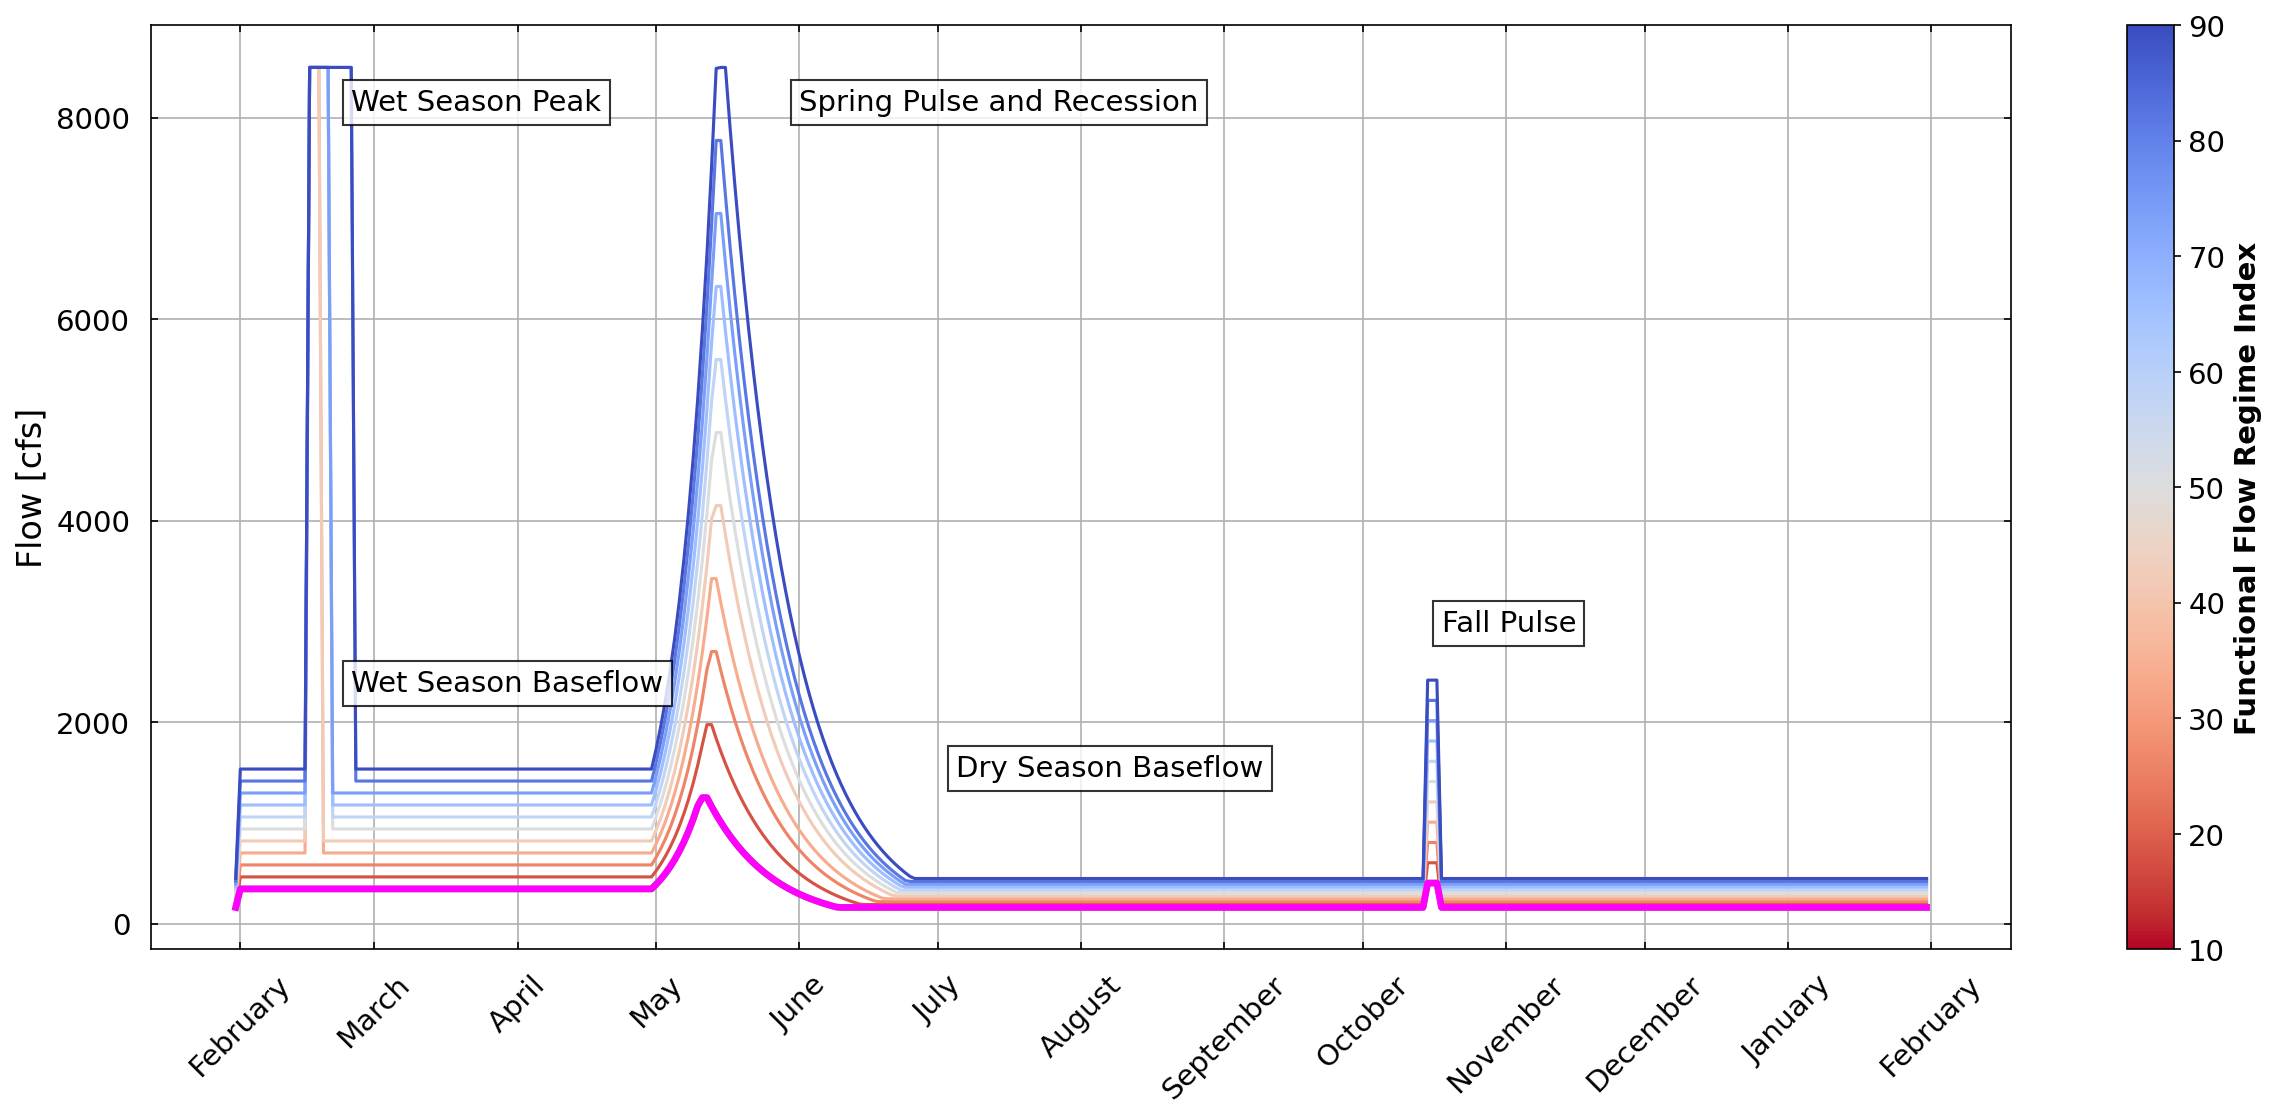

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from ffmPerformanceFunctions import inv_performance_Q_WetBFL_cfs,inv_performance_Q_SP_cfs,inv_performance_Q_DS_cfs,inv_performance_Q_FA_cfs 
from FFM_GeneralFunctions import getDailyFlowPeriodDF, dateToWY
import pandas as pd
HIGHLIGHTSCHEDULE=True
peak_mag=8500

df2=pd.DataFrame()

n=11 #Enter number of lines in the patriotic chart
color_arr = plt.cm.coolwarm_r(np.linspace(0,1,n))
z_arr = np.linspace(10,90,n)

dt_wsp = pd.to_datetime('2020-02-25')
dt_wsb = pd.to_datetime('2020-02-25')
dt_spp = pd.to_datetime('2020-06-01')
dt_spr = pd.to_datetime('2020-06-24')
dt_sbf = pd.to_datetime('2020-07-15')
dt_fp = pd.to_datetime('2020-10-18')

fig, ax = plt.subplots(figsize=(20,8),dpi=150)

for i in range(n):
    z = z_arr[i]
    color = color_arr[i]

    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10
    
    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
    Q_SP = inv_performance_Q_SP_cfs(z)
    Q_DS = inv_performance_Q_DS_cfs(z)
    Q_FA = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)

    df.plot(color=color, ax=ax)
    df2['FFRI_'+str(z)] = df

if HIGHLIGHTSCHEDULE:
    z=10
    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10

    Q_WetBFL1 = inv_performance_Q_WetBFL_cfs(z)
    Q_SP1 = inv_performance_Q_SP_cfs(z)
    Q_DS1 = inv_performance_Q_DS_cfs(z)
    Q_FA1 = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL1, Q_SP1, Q_DS1, Q_FA1)
    df.plot(color='#70AD47', linewidth=3.2, ax=ax, label = 'Flow Schedule with FFRI 60')
    df.plot(color='#FF00FF', linewidth=3.2, ax=ax, label = 'Flow Schedule with FFRI 60')

ax.get_legend().remove()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
_ = plt.xticks(rotation=45)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm_r, norm=plt.Normalize(vmin=10, vmax=90))

cbar = fig.colorbar(sm, label='Functional Flow Regime Index')
ax.set_ylabel('Flow [cfs]',fontsize=16)
cbar.set_label(label='Functional Flow Regime Index', size=14, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.tick_params(axis='both',labelsize=14,direction='in',top=True,right=True, pad = 10)
ax.grid('on')
ax.text(dt_spp,0.95*Q_SP,'Spring Pulse and Recession',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_sbf-dt.timedelta(days=10),0.95*Q_WetBFL,'Dry Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_fp,1.2*Q_FA,'Fall Pulse',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsb,1.5*Q_WetBFL,'Wet Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsp,0.95*Q_SP,'Wet Season Peak',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))

##Comment in to save fig
#fig.savefig('FFR_range.png')

## Comment this in to save daily flows for each of the flow schedules
df2.to_csv('02.22.2024.patriotic_annualhydrographs_NUM.csv')

/var/folders/f8/f6zv3ljd4llc553h77jw10m40000gq/T/ipykernel_89916/3548691676.py:48: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm, label='Functional Flow Regime Index')


Text(2020-02-15 00:00:00, 807.5, 'Wet Season Peak')

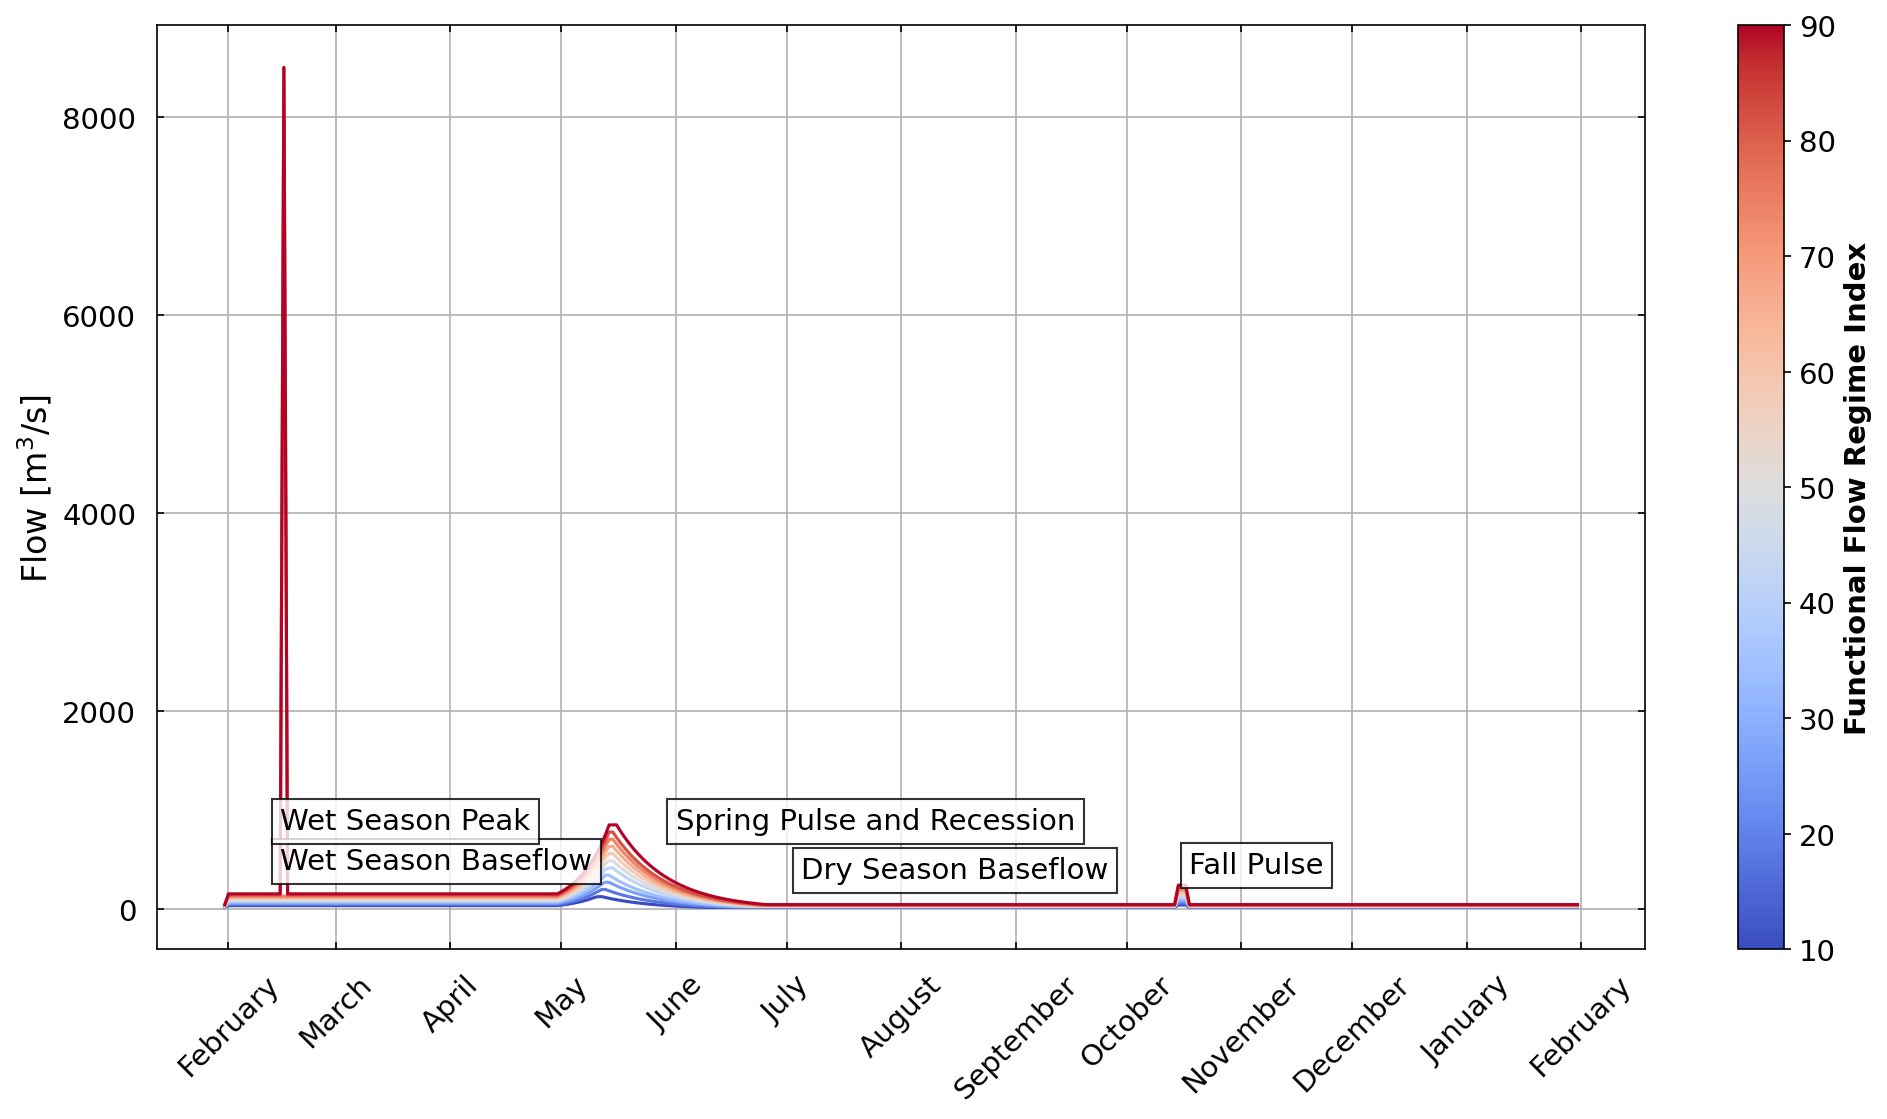

In [2]:
###CMS PATRIOTIC ATTEMPT##

import pandas as pd


n=11
color_arr = plt.cm.coolwarm(np.linspace(0,1,n))
z_arr = np.linspace(10,90,n)

dt_wsp = pd.to_datetime('2020-02-15')
dt_wsb = pd.to_datetime('2020-02-15')
dt_spp = pd.to_datetime('2020-06-01')
dt_spr = pd.to_datetime('2020-06-24')
dt_sbf = pd.to_datetime('2020-07-15')
dt_fp = pd.to_datetime('2020-10-18')

fig, ax = plt.subplots(figsize=(16,8),dpi=150)

for i in range(n):
    z = z_arr[i]
    color = color_arr[i]

    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10
    
    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)/10
    Q_SP = inv_performance_Q_SP_cfs(z)/10
    Q_DS = inv_performance_Q_DS_cfs(z)/10
    Q_FA = inv_performance_Q_FA_cfs(z)/10

    V_WetPeak = peak_dur * ((8500-Q_WetBFL)/10)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)
    df.plot(color=color, ax=ax)
ax.get_legend().remove()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
_ = plt.xticks(rotation=45)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=10, vmax=90))

cbar = fig.colorbar(sm, label='Functional Flow Regime Index')
ax.set_ylabel('Flow [m$^3$/s]',fontsize=16)
cbar.set_label(label='Functional Flow Regime Index', size=14, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.tick_params(axis='both',labelsize=14,direction='in',top=True,right=True, pad = 10)
ax.grid('on')
ax.text(dt_spp,0.95*Q_SP,'Spring Pulse and Recession',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_sbf-dt.timedelta(days=10),2*Q_WetBFL,'Dry Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_fp,1.5*Q_FA,'Fall Pulse',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsb,2.6*Q_WetBFL,'Wet Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsp,0.95*Q_SP,'Wet Season Peak',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))


#fig.savefig('FFR_range_CMS.png')


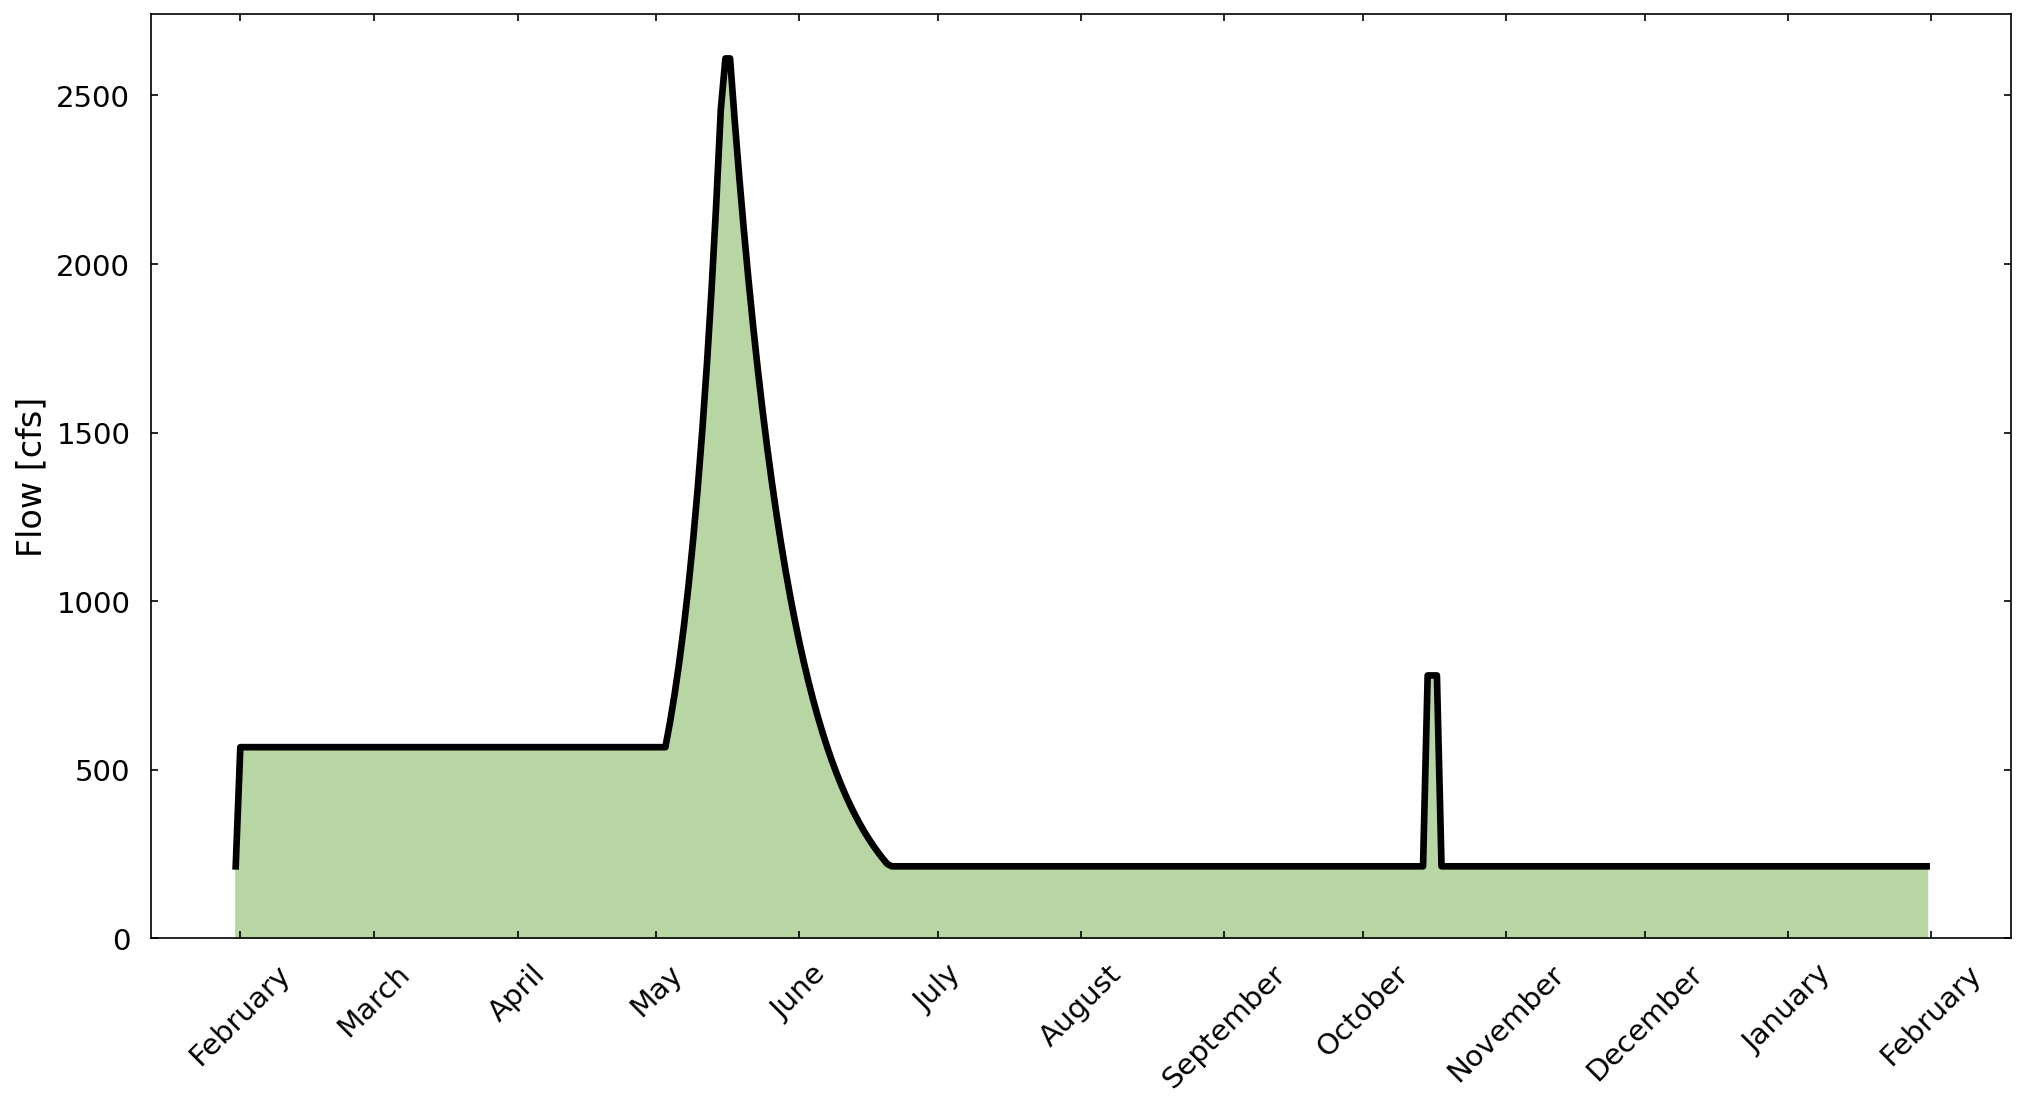

In [3]:

z = 25

dt_wsp = pd.to_datetime('2020-02-15')
dt_wsb = pd.to_datetime('2020-02-15')
dt_spp = pd.to_datetime('2020-06-01')
dt_spr = pd.to_datetime('2020-06-24')
dt_sbf = pd.to_datetime('2020-07-15')
dt_fp = pd.to_datetime('2020-10-18')

fig, ax = plt.subplots(figsize=(16,8),dpi=150)


if z<34:
    peak_dur = 0
elif z<50:
    peak_dur = 3
elif z<75:
    peak_dur = 5
else:
    peak_dur = 10

Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
Q_WetBFL2 = inv_performance_Q_WetBFL_cfs(z+10)
Q_SP = inv_performance_Q_SP_cfs(z)
Q_SP2 = inv_performance_Q_SP_cfs(z+10)
Q_DS = inv_performance_Q_DS_cfs(z)
Q_FA = inv_performance_Q_FA_cfs(z)

V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,4)), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)
#df.plot(color='#70AD47', linewidth=3.2, ax=ax)
df.plot(color='#B7D6A3', kind='area', ax=ax)
df.plot(color='black', linewidth=3.2, ax=ax, alpha=1, label='Flow schedule for a 25th percentile year')

# # +10 spring
# df2 = getDailyFlowPeriodDF(dt.date(2020,4,30), dt.date(2020,6,30), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,4)), V_WetPeak,Q_WetBFL, Q_SP2, Q_DS, Q_FA)
# df2.plot(color='black', linewidth=2.2, linestyle='--', ax=ax, alpha=0, label='45th percentile spring peak magnitude')
# # +10 wet season
# df3 = getDailyFlowPeriodDF(dt.date(2020,2,1), dt.date(2020,5,3), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,4)), V_WetPeak,Q_WetBFL2, Q_SP, Q_DS, Q_FA)
# df3.plot(color='black', linewidth=2.2, linestyle='--', ax=ax, alpha=1, label='45th percentile wet season baseflow magnitude')


ax.get_legend().remove()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
_ = plt.xticks(rotation=45)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=plt.Normalize(vmin=10, vmax=90))

ax.set_ylabel('Flow [cfs]',fontsize=16)
cbar.set_label(label='Functional Flow Regime Index', size=14, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.tick_params(axis='both',labelsize=14,direction='in',top=True,right=True, pad = 10)
#ax.grid('on')
# ax.text(dt_spp,0.95*Q_SP,'Spring Pulse and Recession',fontsize=14,
# 	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
# ax.text(dt_sbf-dt.timedelta(days=10),2*Q_WetBFL,'Dry Season Baseflow',fontsize=14,
# 	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
# ax.text(dt_fp,1.5*Q_FA,'Fall Pulse',fontsize=14,
# 	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
# ax.text(dt_wsb,2.6*Q_WetBFL,'Wet Season Baseflow',fontsize=14,
# 	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
# ax.text(dt_wsp,0.95*Q_SP,'Wet Season Peak',fontsize=14,
# 	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))


# fig.savefig('FF_schedule' + str(z) + '.png')


/var/folders/f8/f6zv3ljd4llc553h77jw10m40000gq/T/ipykernel_89916/2804959184.py:82: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(sm, label='Water Year Percentile')


[Text(0, -2000.0, ''),
 Text(0, 0.0, ''),
 Text(0, 2000.0, ''),
 Text(0, 4000.0, ''),
 Text(0, 6000.0, ''),
 Text(0, 8000.0, ''),
 Text(0, 10000.0, '')]

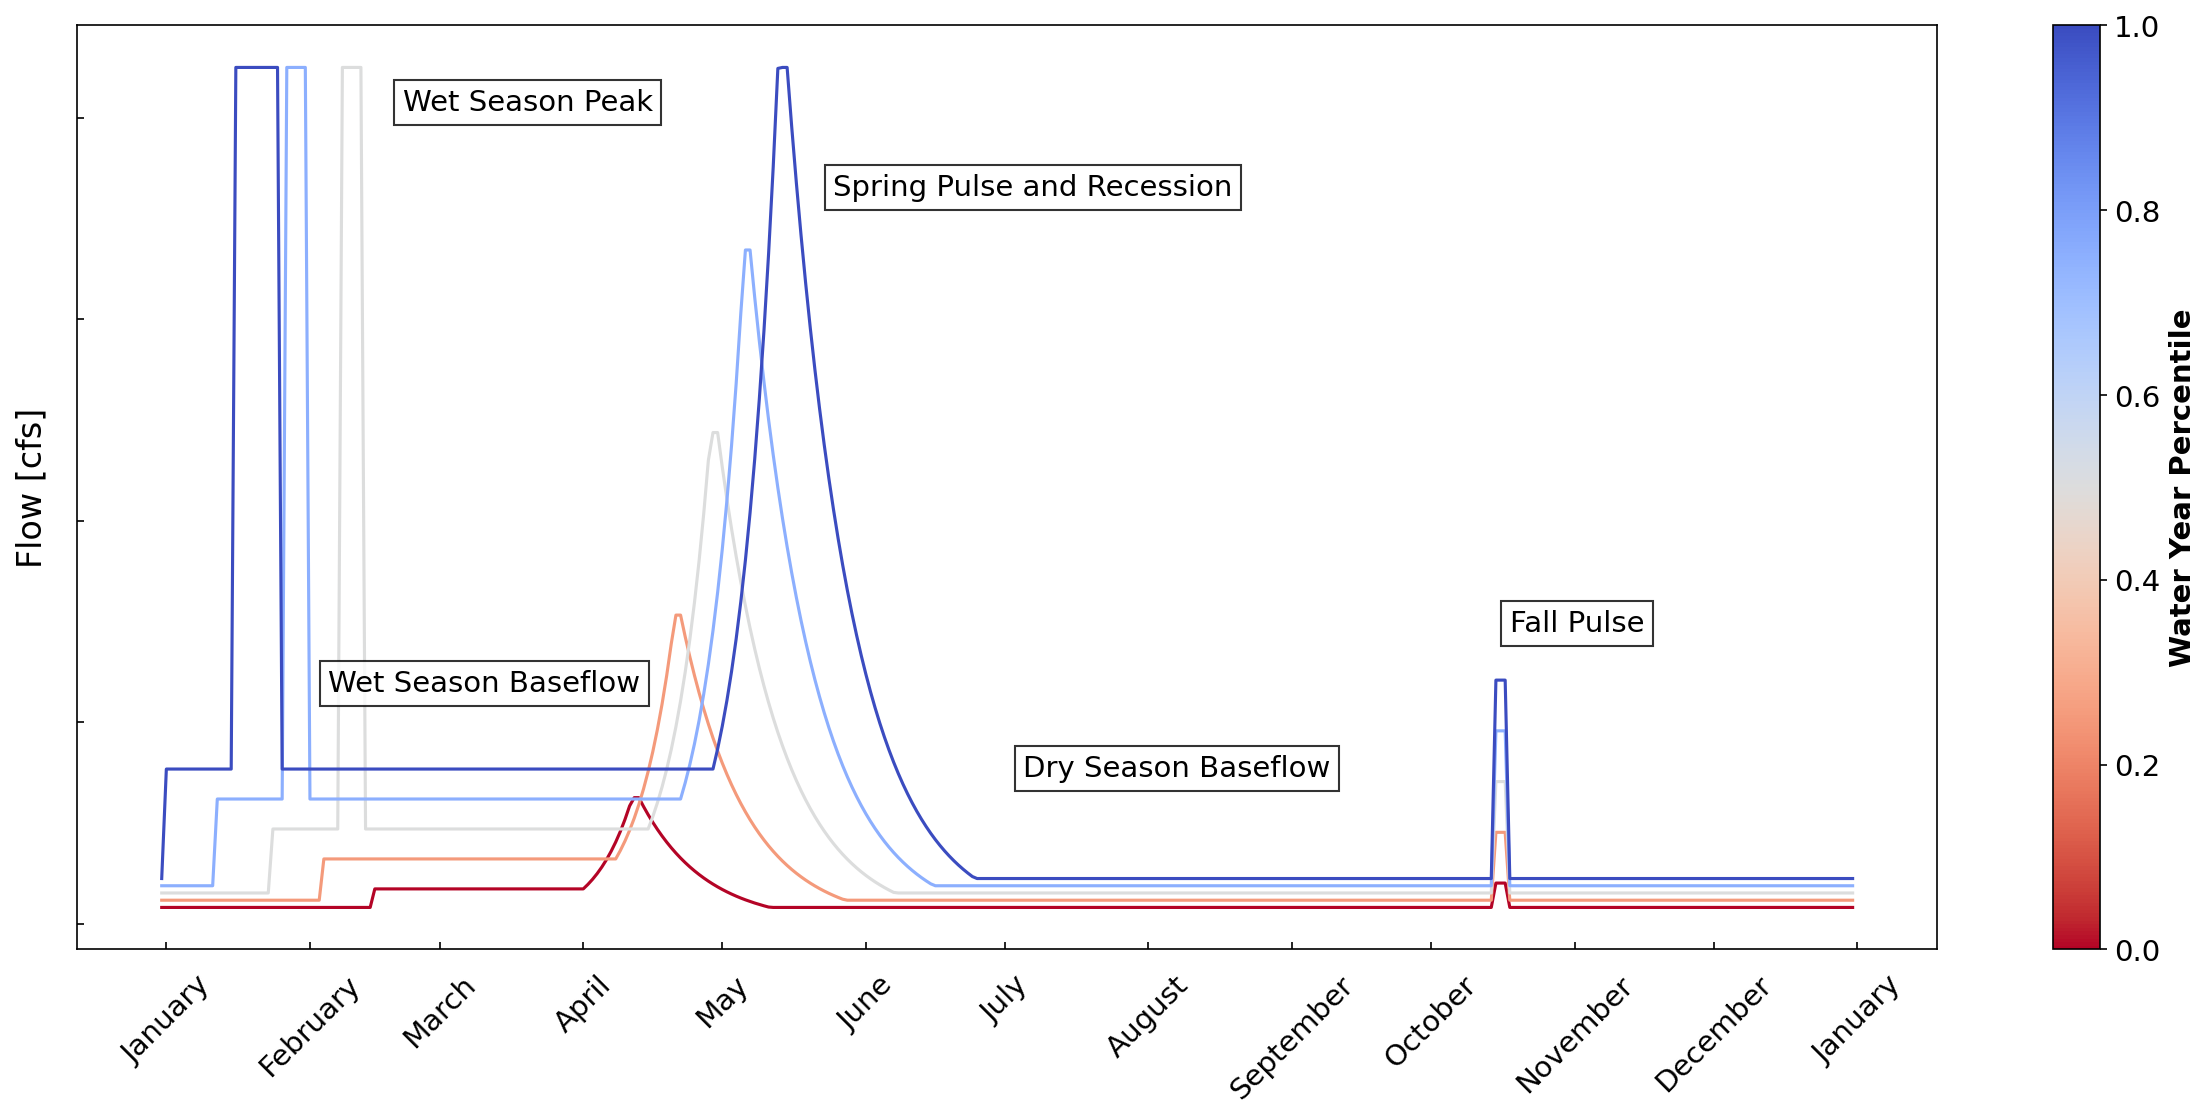

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from ffmPerformanceFunctions import inv_performance_Q_WetBFL_cfs,inv_performance_Q_SP_cfs,inv_performance_Q_DS_cfs,inv_performance_Q_FA_cfs 
from FFM_GeneralFunctions import getDailyFlowPeriodDF, dateToWY
import pandas as pd
HIGHLIGHTSCHEDULE=False


df2=pd.DataFrame()

n=5
color_arr = plt.cm.coolwarm_r(np.linspace(0,1,n))
z_arr = np.linspace(10,90,n)

dt_wsp = pd.to_datetime('2021-02-21')
dt_wsb = pd.to_datetime('2021-02-05')
dt_spp = pd.to_datetime('2021-05-25')
dt_spr = pd.to_datetime('2021-06-24')
dt_sbf = pd.to_datetime('2021-07-15')
dt_fp = pd.to_datetime('2021-10-18')

fig, ax = plt.subplots(figsize=(20,8),dpi=150)

for i in range(n):
    z = z_arr[i]
    color = color_arr[i]

    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10
    
    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
    Q_SP = inv_performance_Q_SP_cfs(z)
    Q_DS = inv_performance_Q_DS_cfs(z)
    Q_FA = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (peak_mag-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,12,31), dt.date(2021,12,31), dateToWY(dt.date(2020,2,15)-dt.timedelta(days=(11.45*i))), dateToWY(dt.date(2020,4,1)+dt.timedelta(days=(i*7))), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)

    df.plot(color=color, ax=ax)
    df2['FFRI_'+str(z)] = df

if HIGHLIGHTSCHEDULE:
    z=65
    if z<34:
        peak_dur = 0
    elif z<50:
        peak_dur = 3
    elif z<75:
        peak_dur = 5
    else:
        peak_dur = 10

    Q_WetBFL = inv_performance_Q_WetBFL_cfs(z)
    Q_SP = inv_performance_Q_SP_cfs(z)
    Q_DS = inv_performance_Q_DS_cfs(z)
    Q_FA = inv_performance_Q_FA_cfs(z)

    V_WetPeak = peak_dur * (8500-Q_WetBFL)

    df = getDailyFlowPeriodDF(dt.date(2020,1,31), dt.date(2021,1,31), dateToWY(dt.date(2020,2,1)), dateToWY(dt.date(2020,5,1)), V_WetPeak,Q_WetBFL, Q_SP, Q_DS, Q_FA)
    df.plot(color='#70AD47', linewidth=3.2, ax=ax, label = 'Flow Schedule with FFRI 60')

ax.get_legend().remove()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%B"))
_ = plt.xticks(rotation=45)
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm_r, norm=plt.Normalize(vmin=0, vmax=1))

cbar = fig.colorbar(sm, label='Water Year Percentile')
ax.set_ylabel('Flow [cfs]',fontsize=16)
cbar.set_label(label='Water Year Percentile', size=14, weight='bold')
cbar.ax.tick_params(labelsize=14)

ax.tick_params(axis='both',labelsize=14,direction='in',top=False,right=False, pad = 10)
#ax.grid('on')
ax.text(dt_spp,0.85*Q_SP,'Spring Pulse and Recession',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_sbf-dt.timedelta(days=10),0.95*Q_WetBFL,'Dry Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_fp,1.2*Q_FA,'Fall Pulse',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsb,1.5*Q_WetBFL,'Wet Season Baseflow',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.text(dt_wsp,0.95*Q_SP,'Wet Season Peak',fontsize=14,
	bbox=dict(facecolor='w', edgecolor='k',alpha=0.8))
ax.set_yticklabels([])

#fig.savefig('FFR_range.png')


#df2.to_csv('testFFRI_annualhydrographs_many.csv')